In [1]:
from utils.paths import DESCRIPTORS_DIR,DATABASE_DIR,RAW_DIR
from plots.PP_Processor import DataCollector
from plots.PP_Plots import Plotter
from features.SignalNoise_Process import SignalProcessor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

import math
import re

In [2]:
dc = DataCollector()
pl = Plotter()
sp = SignalProcessor()

In [3]:
df_compo = pd.read_excel(RAW_DIR/'1_Ternary_exp.xlsx',sheet_name='composition')
com_Cu = df_compo.sort_values("Cu",ascending=False)['Cu'].to_numpy()
com_Ni = df_compo.sort_values("Ni",ascending=False)['Ni'].to_numpy()
com_Al = df_compo.sort_values("Al",ascending=False)['Al'].to_numpy()

In [4]:
df_compo = df_compo.copy()
df_compo = df_compo.dropna()

df_compo['Cu'] = (df_compo["Cu"] * 100).round(2)
df_compo['Ni'] = (df_compo["Ni"] * 100).round(2)
df_compo['Al'] = (df_compo["Al"] * 100).round(2)

df_compo["symbol"] = (
    "Cu" + df_compo["Cu"].astype(str) +
    " Ni" + df_compo["Ni"].astype(str) +
    " Al" + df_compo["Al"].astype(str)
)

SiO2 Measurement

In [5]:
FOLDER = RAW_DIR/"_1st_bad_data_no_removed"
files_index_1, selected_1 = dc.extract_file_names(FOLDER, pattern= re.compile(
    r"""
    sample(?P<sample>\d+)          # sample1 -> 1
    .*?                            # anything in between
    pump_(?P<power>\d+)p0mW        # pump_2p0mW -> 2
    """,
    
    re.VERBOSE
),select_power='max')

In [6]:
master_wvl_1 = dc.build_master(selected_1, smooth="wvl", method="savgol", savgol_window=51, savgol_poly=3)
master_time_1 = dc.build_master(selected_1, smooth="time", method="gaussian", gaussian_sigma=3)

Transmission Measuremente

In [7]:
FOLDER = RAW_DIR/"_1st_transmission"
files_index, selected = dc.extract_file_names(FOLDER, pattern= re.compile(
    r"""
    Sample(?P<sample>\d+)        # Sample8 → 8
    .*?                          # anything in between
    (?P<power>\d+)p0mW           # 4p0mW → 4
    .*?                          # anything
    pump_                        # pump_
    """,
    
    re.VERBOSE
),select_power='max')

Substrate data

In [8]:
master_wvl = dc.build_master(selected, smooth="wvl", method="savgol", savgol_window=51, savgol_poly=3)
master_time = dc.build_master(selected, smooth="time", method="gaussian", gaussian_sigma=3)

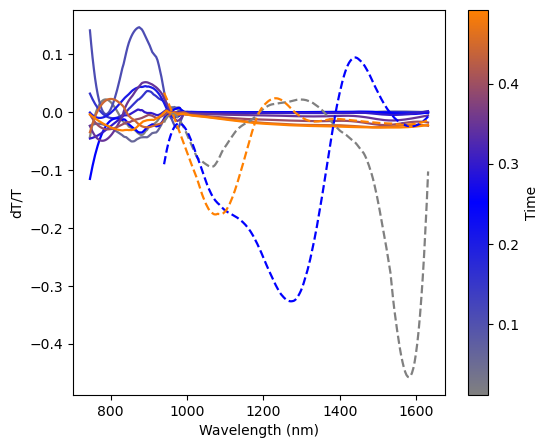

In [9]:
df1 = master_wvl[3].drop(columns=['sample','power_mW'])
df2 = master_wvl_1[3].drop(columns=['sample','power_mW'])

fig, ax = plt.subplots(figsize=(6, 5))

pl.plot_spectra_at_times(
    df1,
    time_range=(0, 0.5),
    step=4,
    legend=False,
    ax=ax,
    linestyle="-",
    add_colorbar=True
)

pl.plot_spectra_at_times(
    df2,
    time_range=(0, 0.5),
    step=5,
    legend=False,
    ax=ax,
    linestyle="--",
    add_colorbar=False
)

plt.show()

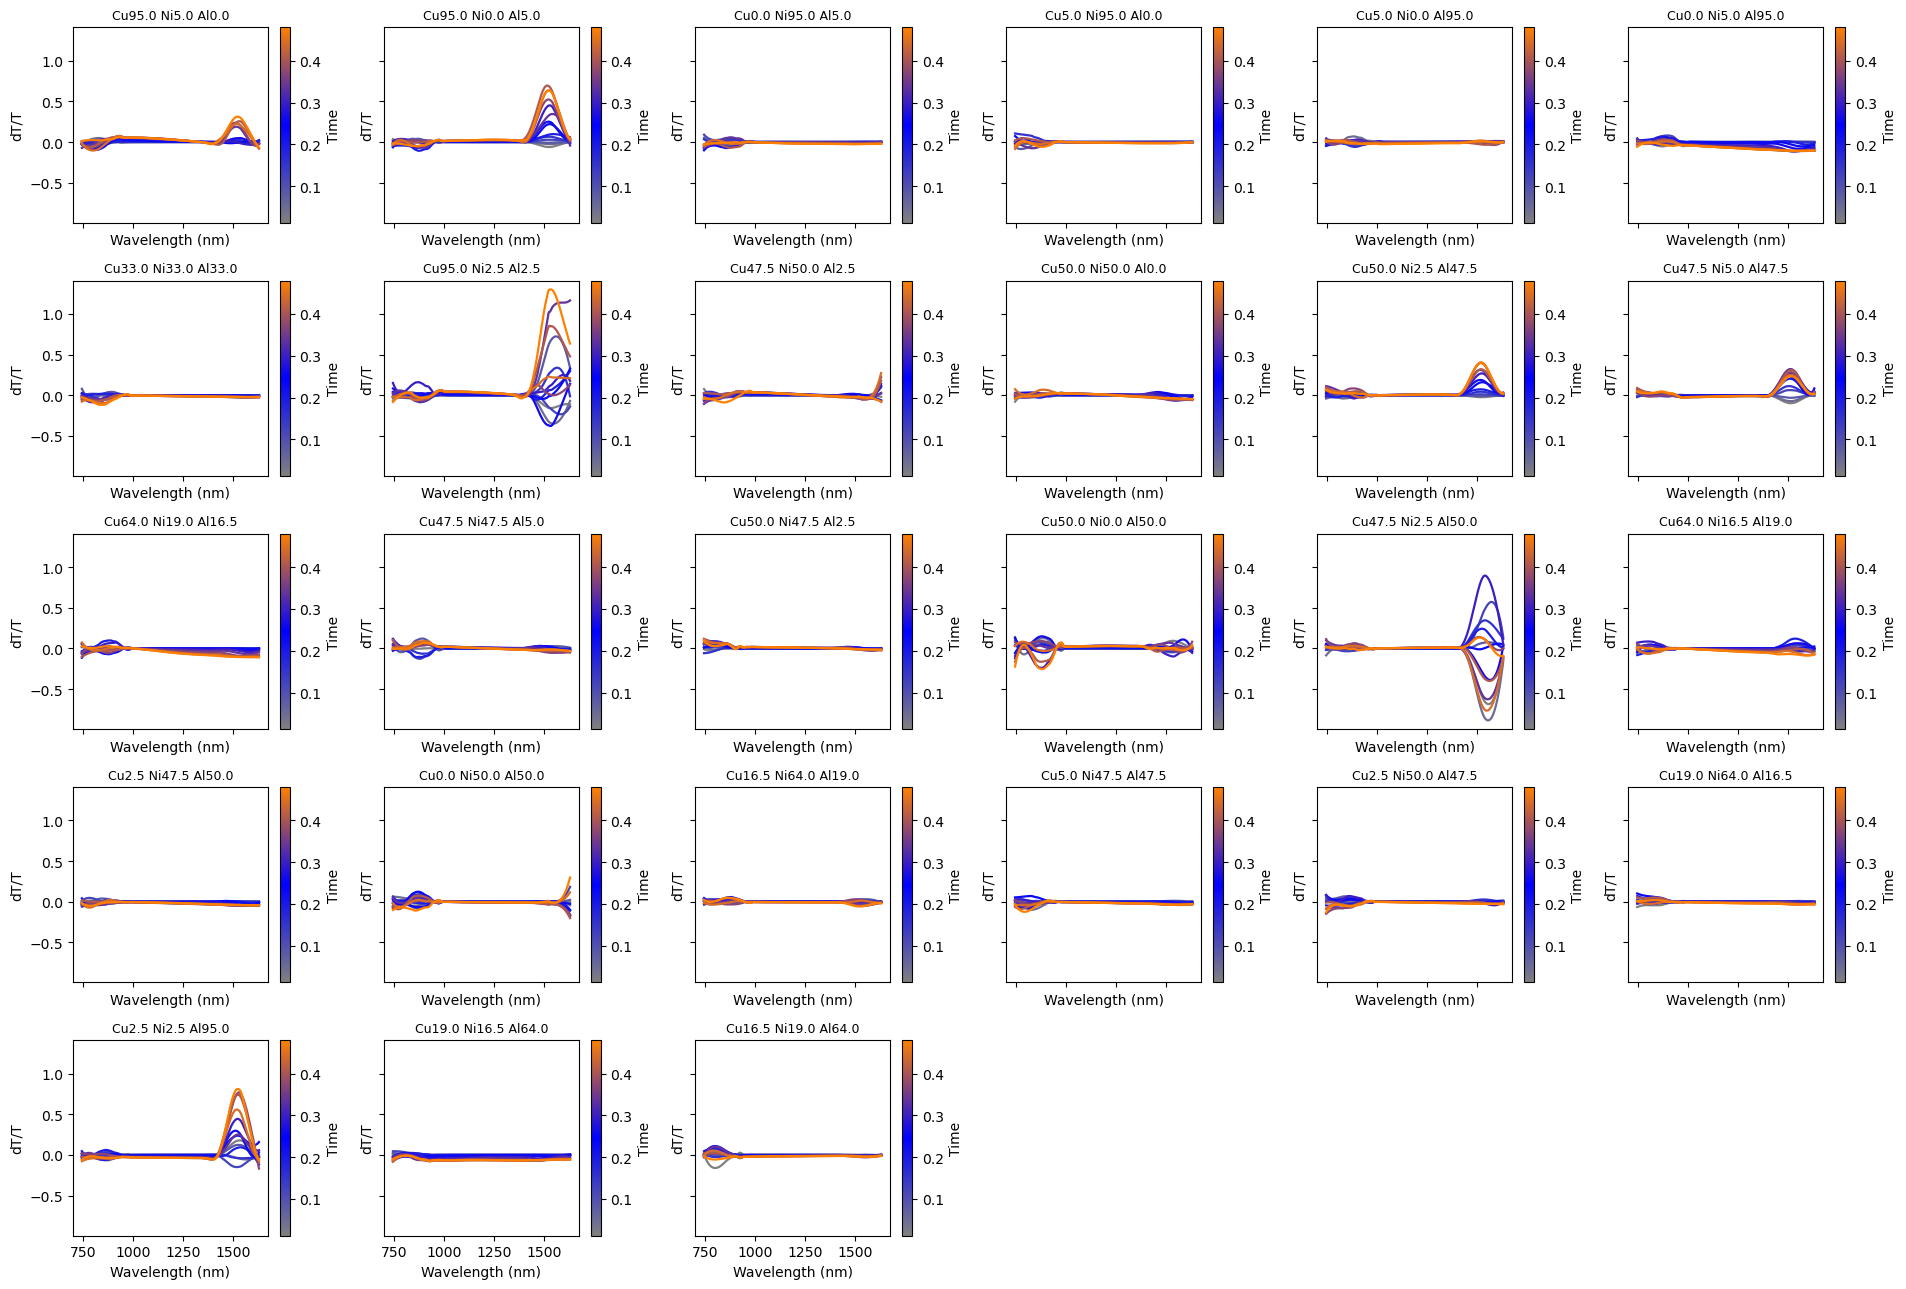

In [30]:
sample_data = np.array(list(master_wvl.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()

for ax, sample in zip(axes, sample_data):
    df = master_wvl[sample].drop(columns=["sample", "power_mW"])

    pl.plot_spectra_at_times(
        df,
        time_range=(0, 0.5),
        step=3,
        legend=False,
        ax=ax,         
        add_colorbar=True,
        figsize=(6,5)  
    )
    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

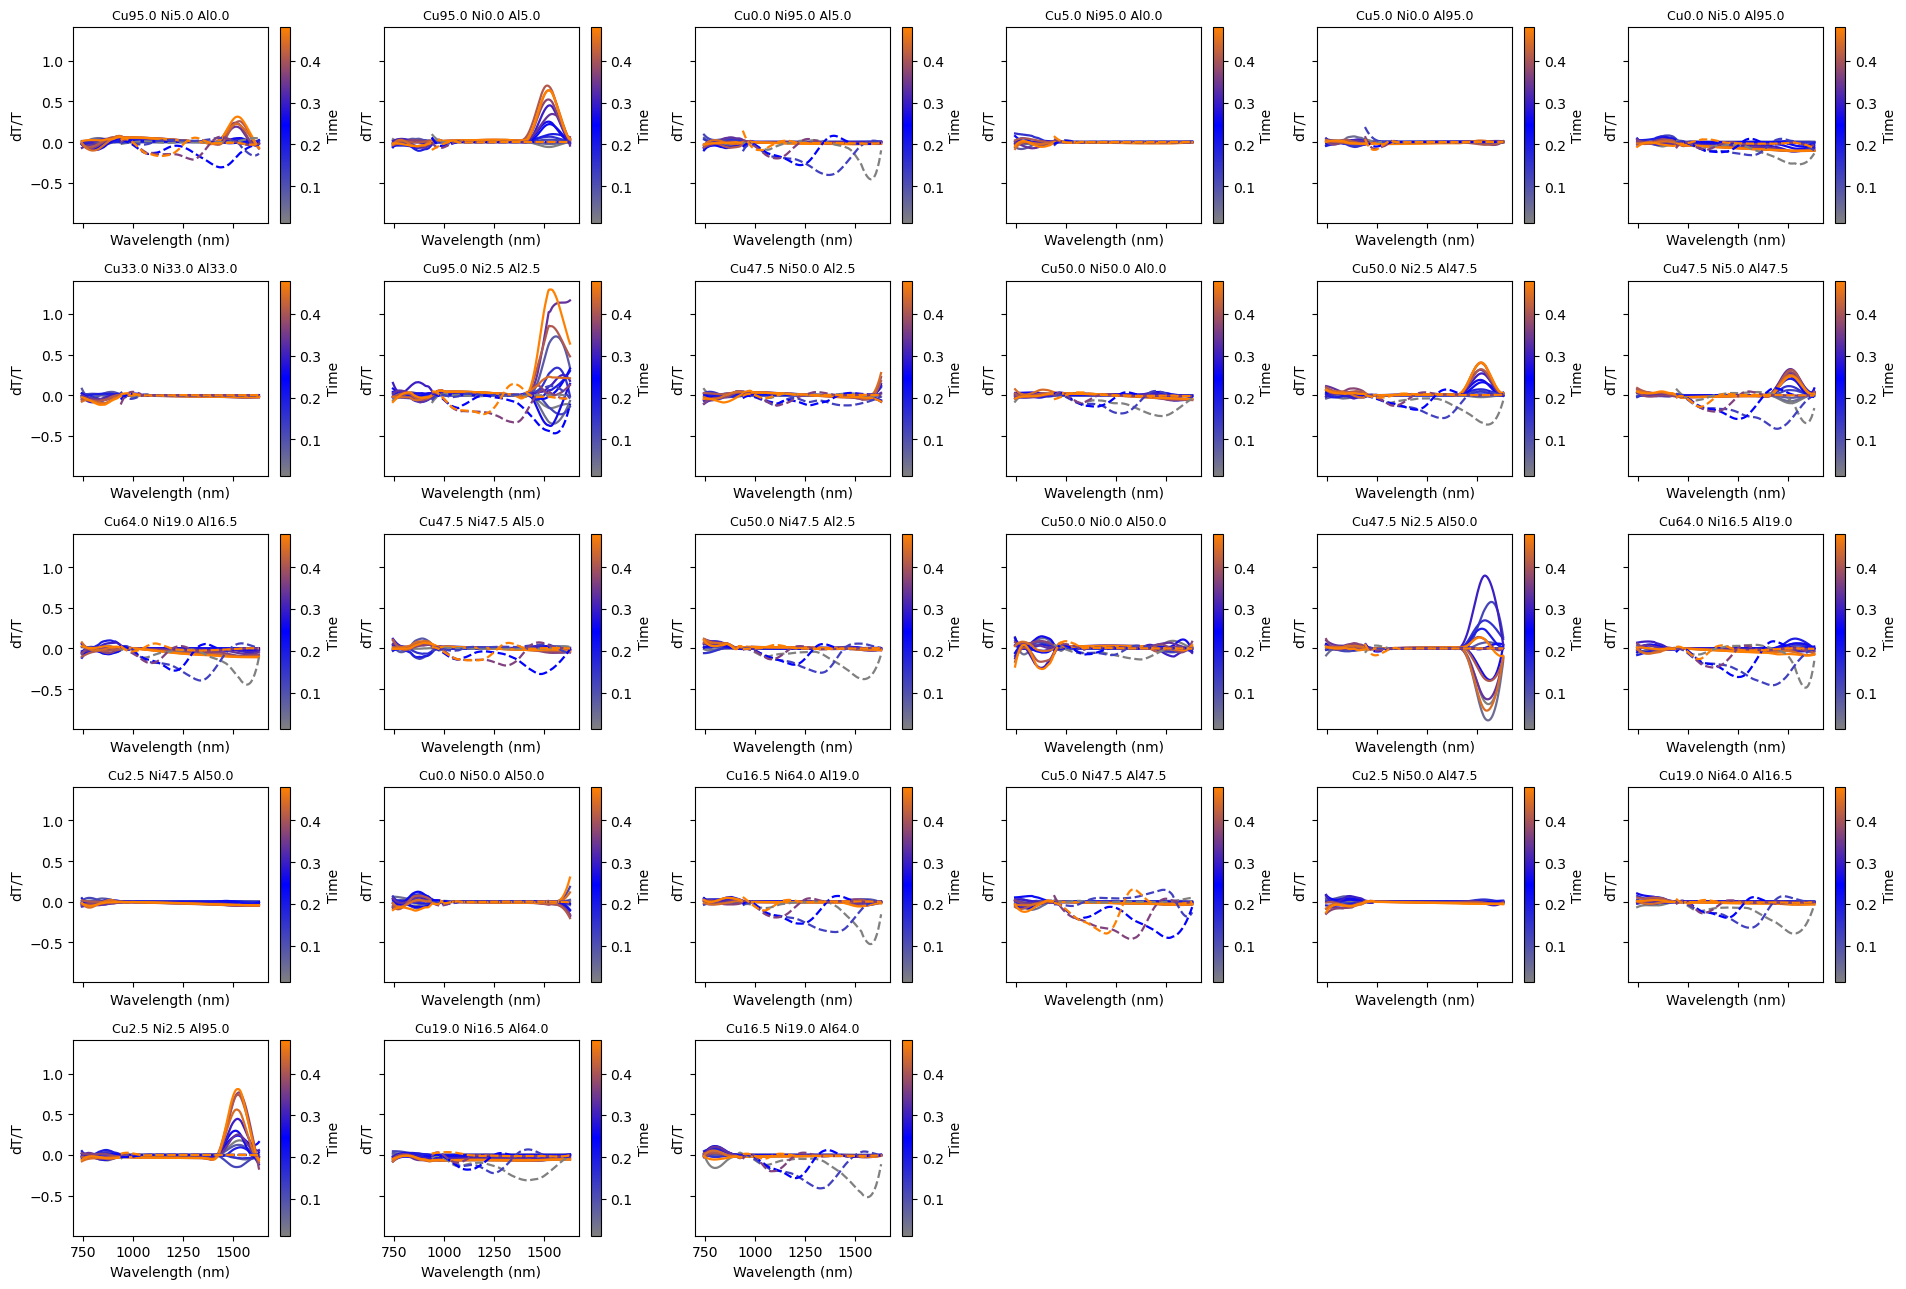

In [11]:
sample_data = np.array(list(master_wvl.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()

for ax, sample in zip(axes, sample_data):
    df1 = master_wvl[sample].drop(columns=["sample", "power_mW"])

    # always plot the first dataframe
    pl.plot_spectra_at_times(
        df1,
        time_range=(0, 0.5),
        step=3,
        legend=False,
        ax=ax,
        add_colorbar=True,
        linestyle="-"
    )

    # plot the second dataframe only if that sample exists there
    if sample in master_wvl_1:
        df2 = master_wvl_1[sample].drop(columns=["sample", "power_mW"])

        pl.plot_spectra_at_times(
            df2,
            time_range=(0, 0.5),
            step=3,
            legend=False,
            ax=ax,
            add_colorbar=False,
            linestyle="--"
        )

    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Kinetic Plot

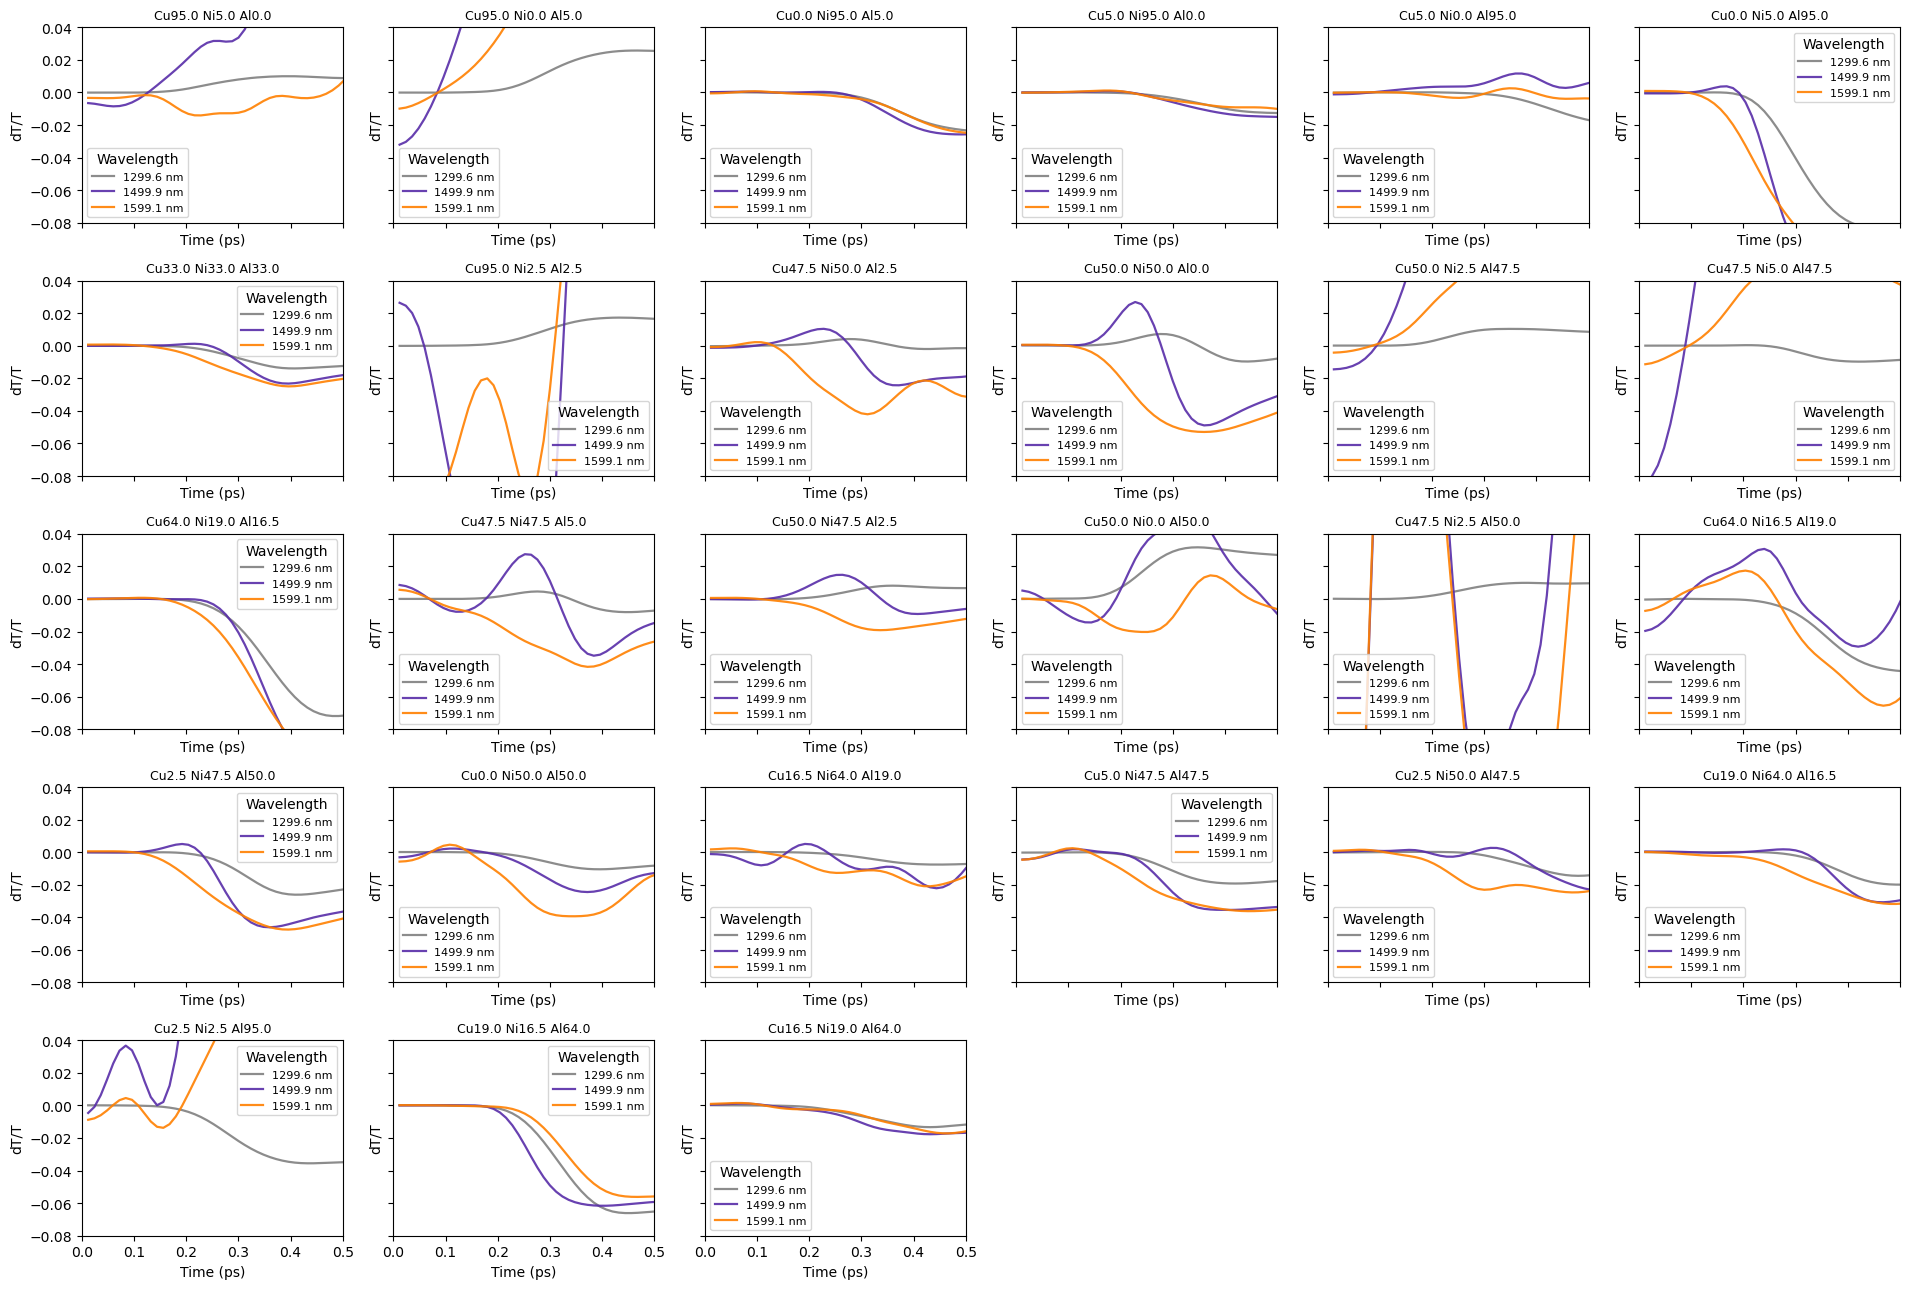

In [31]:
sample_data = np.array(list(master_time.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to 1D list of axes

for ax, sample in zip(axes, sample_data):
    df = master_time[sample]
    df = df.drop(columns=['sample', 'power_mW'])
    pl.kinetic_plot(df,wavelengths= [1300,1500,1600] ,
                    xlim=(0, 0.5),
                    ylim = (-0.08,0.04),
                    ax=ax,
                    legend=True,
                    add_colorbar=False )
    
    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)


for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

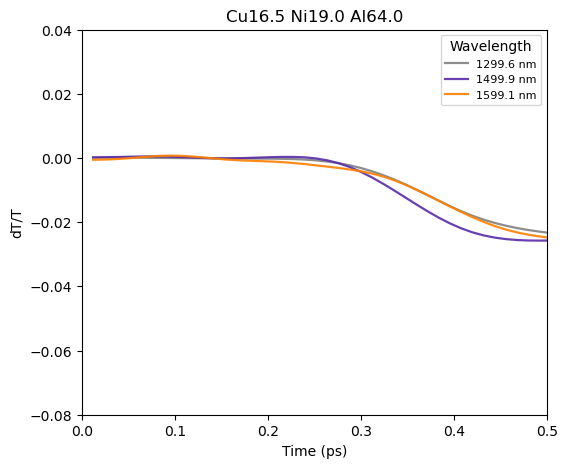

In [29]:
df = master_time[3].drop(columns=['sample', 'power_mW'])

fig, ax = plt.subplots(figsize=(6,5))

pl.kinetic_plot(
    df,
    wavelengths=[1300, 1500, 1600],
    xlim=(0, 0.5),
    ylim=(-0.08, 0.04),
    ax=ax,
    legend=True,
    add_colorbar=False
)

title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
ax.set_title(title)

plt.show()

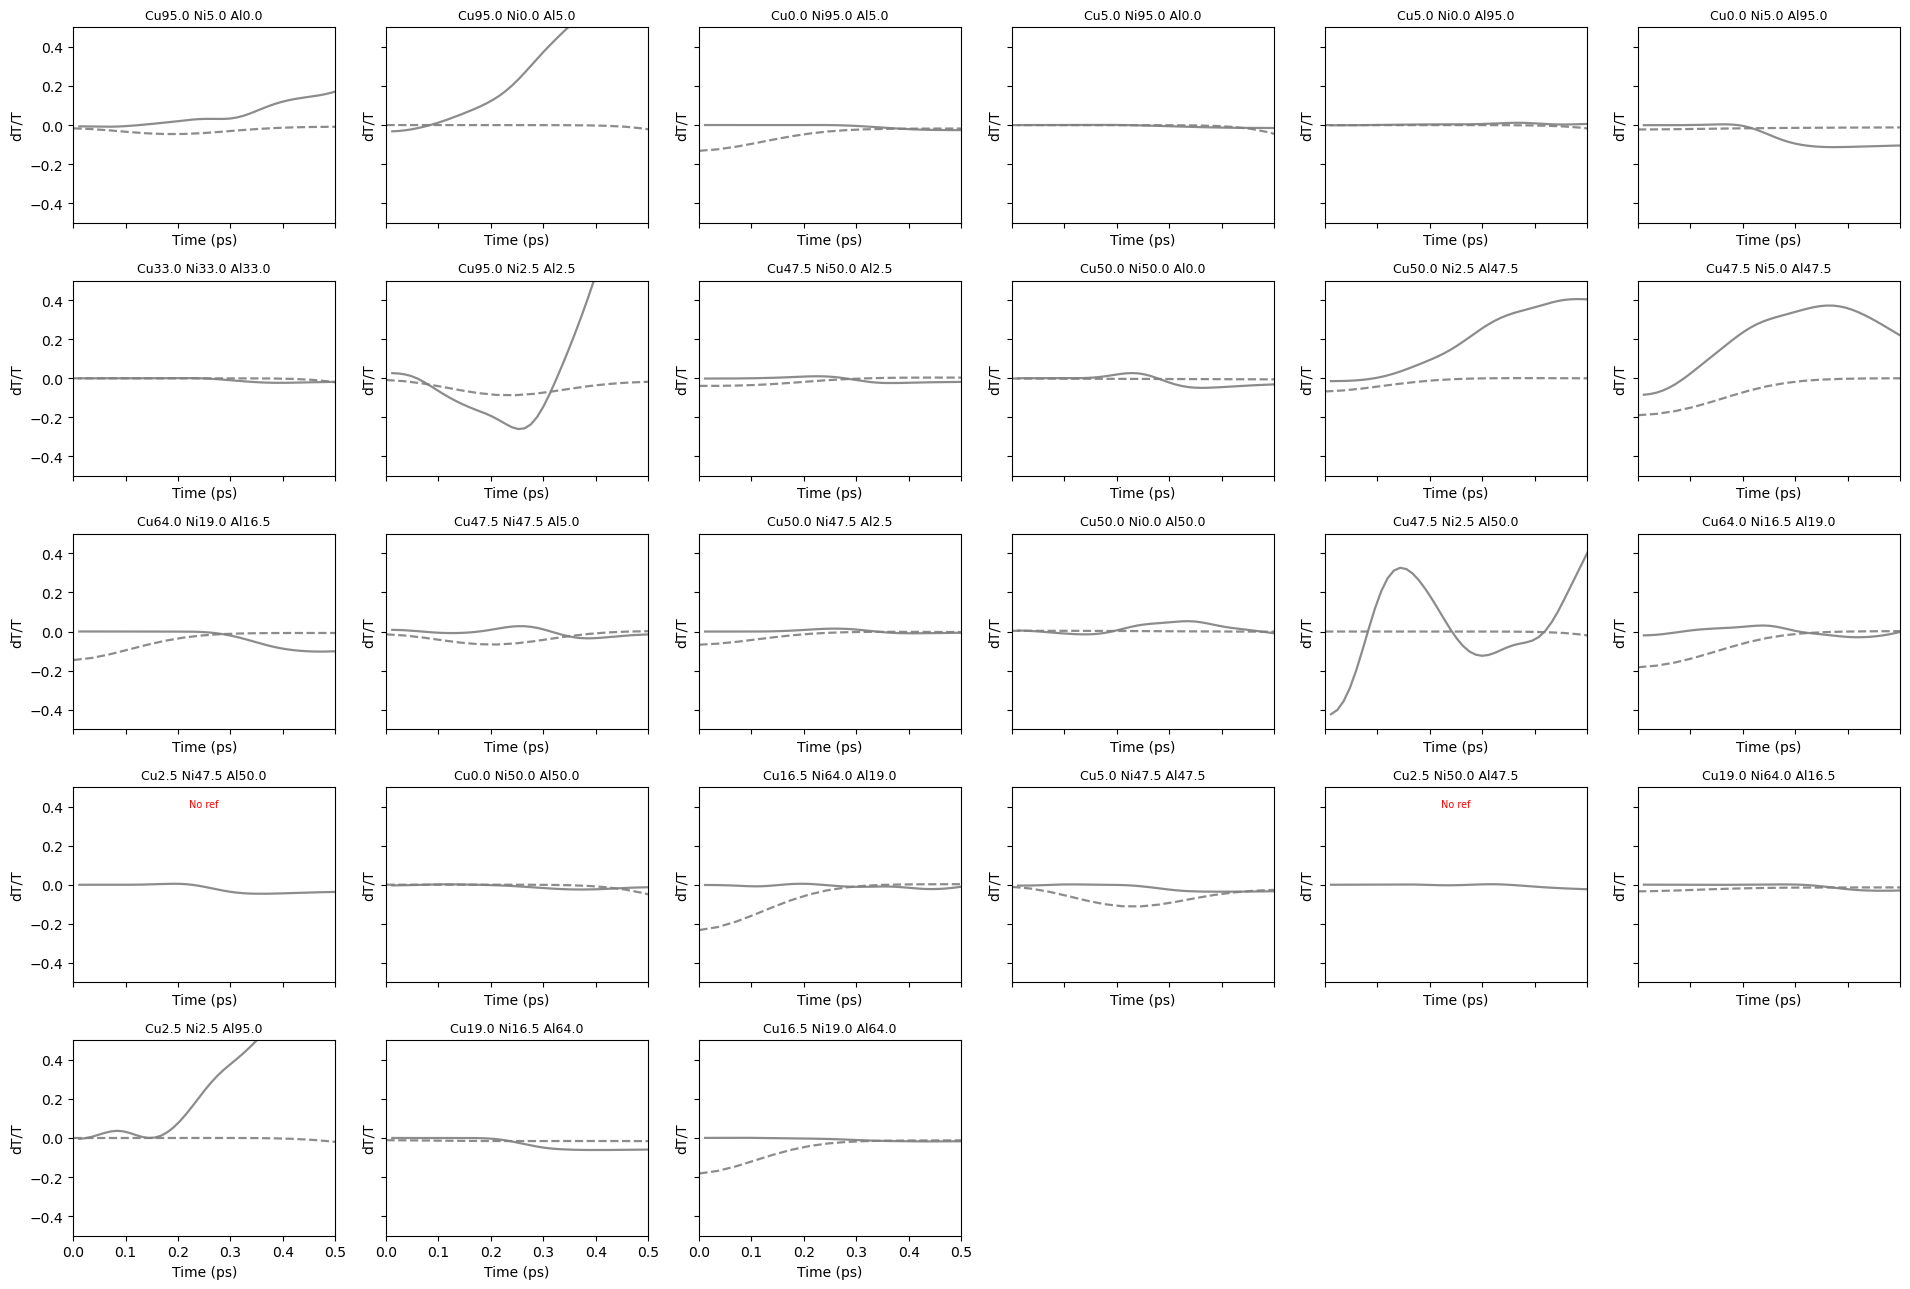

In [33]:
sample_data = np.array(list(master_time.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()

for ax, sample in zip(axes, sample_data):
    df1 = master_time[sample].drop(columns=['sample', 'power_mW'])

    # --- Transmission ---
    pl.kinetic_plot(
        df1,
        wavelengths=1500,
        xlim=(0, 0.5),
        ylim= (-0.5,0.5),
        ax=ax,
        legend=False,
        add_colorbar=False,
        linestyle="-"
    )

    # --- SiO2 ---
    if sample in master_time_1:
        df2 = master_time_1[sample].drop(columns=['sample', 'power_mW'])

        pl.kinetic_plot(
            df2,
            wavelengths=1500,
            xlim=(0, 0.5),
            ylim= (-0.5,0.5),
            ax=ax,
            legend=False,
            add_colorbar=False,
            linestyle="--"
        )

    # --- title ---
    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

    # --- Indication of the missing composition ---
    if sample not in master_time_1:
        ax.text(
            0.5, 0.9, "No ref",
            transform=ax.transAxes,
            ha="center",
            fontsize=7,
            color="red"
        )

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

In [ ]:
sample_data = np.array(list(master_time.keys()))
n = len(sample_data)

ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.2 * ncols, 2.6 * nrows),
    sharex=True, sharey=True
)

axes = axes.ravel()

df_sub = df_sub = master_time_sub[1].copy()
df_sub = df_sub.drop(columns=["sample", "power_mW"], errors="ignore")

df_sub_2 = master_time_sub[2].copy()
df_sub_2 = df_sub_2.drop(columns=["sample", "power_mW"], errors="ignore")

for ax, sample in zip(axes, sample_data):
    df = master_time[sample].copy()
    df = df.drop(columns=["sample", "power_mW"], errors="ignore")

    pl.kinetic_plot(
        df,
        wavelengths=[1320],
        xlim=(0, 1),
        ax=ax,
        legend=False,
        add_colorbar=False,
        cmap_colors = ((68, 1, 84), (59, 82, 139), (253, 231, 37))
    )

    pl.kinetic_plot(
        df_sub,
        wavelengths=[1320],
        xlim=(0, 1),
        ax=ax,
        legend=False,
        add_colorbar=False,
        linestyle="--",
         cmap_colors = ((68, 1, 84), (59, 82, 139), (253, 231, 37))
    )
    
    pl.kinetic_plot(
        df_sub_2,
        wavelengths=[1320],
        xlim=(0, 1),
        ax=ax,
        legend=False,
        add_colorbar=False,
        linestyle=":",
         cmap_colors = ((68, 1, 84), (59, 82, 139), (253, 231, 37))
    )

    title = df_compo.loc[df_compo["ID"] == sample, "symbol"].iloc[0]
    ax.set_title(title, fontsize=9)

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Lifetime calculation

In [21]:
lt = LifetimeFitter()

In [55]:
wvl = 1300

df = master_time[6]
columns = ['sample','power_mW']
df = df.drop(columns=columns)

x = df.columns.to_numpy()
idx = np.abs(df.index.to_numpy(dtype=float) - wvl).argmin()

y = df.iloc[idx].to_numpy(dtype=float)

lifetime = lt.fit(time=x, y_exp=y)


lifetime = {}
wvl = 1308.8

for key, df in master_dfs.items():
    df = df.drop(columns=['sample', 'power_mW'])


    x = df.columns.to_numpy()

    idx = np.abs(df.index.to_numpy(dtype=float) - wvl).argmin()
    y = df.iloc[idx].to_numpy(dtype=float)

    lifetime[key] = lt.fit(time=x, y_exp=y)

In [32]:

def plot_lifetime_fit(
    lifetime: dict,
    #key,
    time,
    y_exp,
    time_range=None,          # NEW: (tmin, tmax)
    figsize=(6, 4),
):
    """
    Plot experimental data vs fitted curve for a given key,
    optionally restricting to a time range.
    """

    fit_out = lifetime
    y_fit = fit_out["y_fit"]
    r2 = fit_out.get("r2", None)

    time = np.asarray(time, dtype=float)
    y_exp = np.asarray(y_exp, dtype=float)
    y_fit = np.asarray(y_fit, dtype=float)

    if time_range is not None:
        tmin, tmax = time_range
        mask = (time >= tmin) & (time <= tmax)
    else:
        mask = slice(None)

    plt.figure(figsize=figsize)
    plt.plot(time[mask], y_exp[mask], "o", label="exp")

    if r2 is not None:
        plt.plot(time[mask], y_fit[mask], "-", label=f"fit (R² = {r2:.3f})")
    else:
        plt.plot(time[mask], y_fit[mask], "-", label="fit")

    if time_range is not None:
        plt.xlim(time_range)

    plt.xlabel("Time (ps)")
    plt.ylabel("dT/T")
    plt.legend()
    plt.tight_layout()
    plt.show()

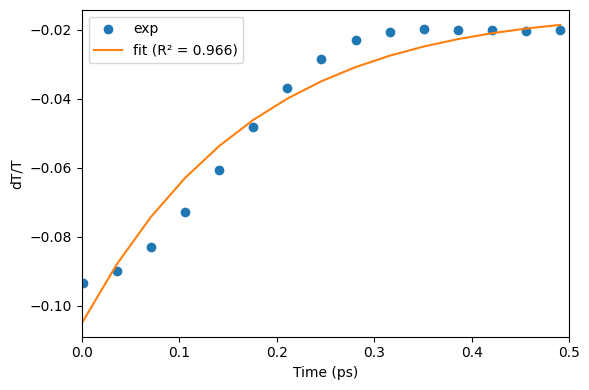

In [76]:
plot_lifetime_fit(
    lifetime=lifetime,
    time=x,
    y_exp=y,
    time_range=(0, 0.5),
)

Lifetime equation fitting
1. Functions of the equation and the objective function
2. Find initial guesses
3. Gradient-based search to find the minimum

In [79]:
PATH_TEST = RAW_DIR / 'TTM_Test_Data.xlsx'
df_test = pd.read_excel(PATH_TEST,sheet_name='Au50Pd50')

df_test.head(5)
y_exp = df_test['dT/T exp'].to_numpy()
time_sara = df_test['time (ps)'].to_numpy()
y_fit_sara = df_test['dT/T Fit'].to_numpy()

In [82]:
lifetim_sara = lt.fit(time=time_sara, y_exp=y_exp)
residuals = lifetim_sara['residual']
y_fit_model = lifetim_sara['y_fit']

p0_sara = [-1.08e-2,0.139898,0.74371,-6.28e-2,0.017520945]

In [83]:
residual_s = (y_fit_sara - y_exp)**2
mse_s = np.mean(residual_s)
print('MSE:',mse_s)

MSE: 1.2135957117079583e-06


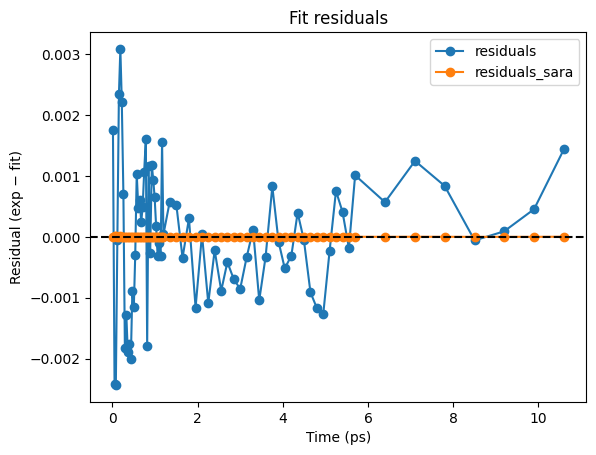

In [84]:
plt.plot(time_sara, residuals, marker='o', label='residuals')
plt.plot(time_sara, residual_s, marker='o', label='residuals_sara')

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Time (ps)")
plt.ylabel("Residual (exp − fit)")
plt.title("Fit residuals")
plt.legend()
plt.show()

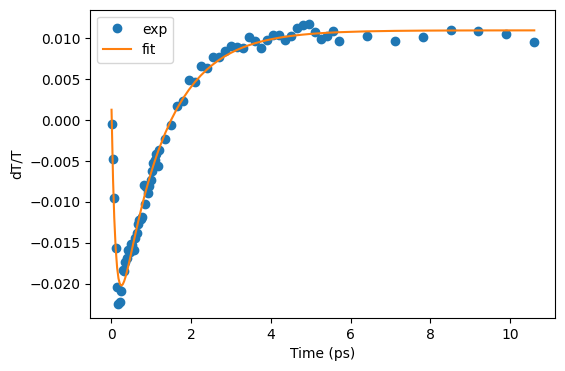

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(time_sara, y_exp, 'o', label="exp")
plt.plot(time_sara, y_fit_model, '-', label="fit")
plt.plot(time_sara, y_fit_sara, '-', label="Sara_fit")
plt.xlabel("Time (ps)")
plt.ylabel("dT/T")
plt.legend()
plt.show()